<style>
      body {
        color: #03234B;
        background: #242b2e;
        padding: 20px;
        font-family: "Roboto", sans-serif !important
      }
</style>
<p><?xml version="1.0" encoding="utf-8"?>
<!-- Generator: Adobe Illustrator 24.0.2, SVG Export Plug-In . SVG Version: 6.00 Build 0)  -->
<svg height="150" version="1.1" id="Logo_1_" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" x="0px" y="0px"
	 viewBox="0 0 549.62 209.54" style="enable-background:new 0 0 549.62 209.54;" xml:space="preserve">
<style type="text/css">
	.st0{fill:#03234B;}
</style>
<g>
	<g>
		<path class="st0" d="M269.27,47.01l-156.74,0.01c0,0,0.01,0.01,0.01,0.01c-11.89,0-22.11,7.11-26.55,17.25l-30.94,74.53
			c-0.08,0.2-0.13,0.4-0.13,0.63c0,0.89,0.74,1.62,1.64,1.62l70.77,0c5.03,0,7.22-4.84,3.3-8.71l-25.99-24.32
			c-13.66-13.39-7.8-44.44,20.57-44.44h138.55c0.72,0,1.33-0.46,1.55-1.09l5.48-13.25c0.08-0.19,0.12-0.4,0.12-0.62
			C270.9,47.74,270.18,47.01,269.27,47.01z"/>
		<path class="st0" d="M253.65,84.95l-26.61,0.03c-1.79,0-3.34,1.08-3.98,2.63l-29.81,72.03c-0.12,0.22-0.19,0.48-0.19,0.75
			c0,0.89,0.73,1.61,1.63,1.61l9.93,0l0-0.01c12.06,0,22.47-7.3,26.81-17.67c0,0,0.02,0.01,0.03,0.02l23.69-57.19
			c0.07-0.19,0.12-0.39,0.12-0.6C255.29,85.67,254.55,84.95,253.65,84.95z"/>
		<path class="st0" d="M201.35,86.56c0-0.9-0.74-1.62-1.64-1.62h-75.44c-4.09,0-7.67,5.03-3.34,9.02l24.92,23.19
			c0,0,10.09,9.3,7.93,22.61c-1.91,11.72-9.9,18.89-15.69,21.47l-0.02,0c-0.14,0.07-0.23,0.21-0.23,0.36c0,0.22,0.18,0.41,0.41,0.41
			l29.07,0c1.8,0,3.34-1.08,3.98-2.63l29.92-72.24C201.31,86.95,201.35,86.76,201.35,86.56z"/>
	</g>
</g>
</svg>
</p>



In [71]:
# IMPORT
import os
import re
import json
import shutil
import datetime
import warnings
import numpy as np

# import qgrid as qg
import pandas as pd
import plotly.io as pio
import plotly_express as px
import ipywidgets as widgets
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from bs4 import BeautifulSoup
from io import StringIO

from scipy.interpolate import interp1d
from plotly.subplots import make_subplots
from IPython.display import Markdown, display, HTML
from pandas.errors import EmptyDataError, ParserError

import utility as uty

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = [16, 9]
read_from_stdf = False
pd.set_option("display.max_columns", None)
pio.renderers.default = "notebook"
last_timestamp = datetime.datetime.now()

p = os.listdir()
stdflist = []
for i in p:
    if "cfg.json" in i:
        try:
            with open(i, "r") as file:
                content = file.read()
                if not content.strip():
                    raise ValueError(f"The file {i} is empty.")
                parameter = json.loads(content)

        except FileNotFoundError:
            uty.write_log(f"File {i} not found.")
        except json.JSONDecodeError as e:
            uty.write_log(f"Error decoding JSON from file {i}: {e}")
        except KeyError as e:
            uty.write_log(f"Missing key in JSON data from file {i}: {e}")
        except ValueError as e:
            uty.write_log(e)


STblue = "#03234B"
STcyan = "#3CB4E6"
STred = "#E6007E"
STyellow = "#FFD200"
STgreen = "#49B170"
STViolet = "#8C0078"
STdarkgreen = "#04572F"
STPalette = ["#03234B", "#3CB4E6", "#FFD200", "#E6007E", "#49B170", "#8C0078", "#04572F"]
STHBIN = [
    "#49B170",
    "#03234B",
    "#3CB4E6",
    "#FFD200",
    "#E6007E",
    "#8C0078",
    "#04572F"
]

STblue = uty.get_personalization(parameter, "STblue" ,STblue)
STcyan = uty.get_personalization(parameter, "STcyan",STcyan)
STred = uty.get_personalization(parameter, "STred",STred)
STyellow = uty.get_personalization(parameter, "STyellow",STyellow)
STgreen = uty.get_personalization(parameter, "STgreen",STgreen)
STViolet = uty.get_personalization(parameter, "STViolet",STViolet)
STdarkgreen = uty.get_personalization(parameter, "STdarkgreen",STdarkgreen)
STHBIN = uty.get_personalization(parameter, "STHBIN",STHBIN)
STPalette = uty.get_personalization(parameter, "STPalette",STPalette)
xwafer = uty.get_personalization(parameter, "xwafer")
ywafer = uty.get_personalization(parameter, "ywafer")

In [72]:
#FOLLOW MD IS STYLE BUTTON AND LOADING

<style>
  html {
    scroll-behavior: smooth;
  }
  .contentconteiner {
  	display: flex;
  	flex-wrap: wrap;
  	justify-content: center;
  	align-items: center;
  	margin: 0 auto;
  	max-width: 800px;
  	padding: 20px;
  }
 .btn {
  	border: none;
  	text-align: center;
  	text-decoration: none;
  	display: inline-flex;
    flex: 1;
  	margin: 10px;
  	cursor: pointer;
  	transition-duration: 0.4s;
    padding: 10px 0px;
    height: auto;
    max-width: auto;
    background: unset;
    justify-content: center;
    text-decoration: underline;
    color: var(--jp-ui-font-color1);
  }
  .jp-RenderedHTMLCommon a:link, 
  .jp-RenderedHTMLCommon a:visited {
      text-decoration: underline;
      background: unset;
      color: var(--jp-ui-font-color1);

  }
  .btn:hover,
  .jp-RenderedHTMLCommon a:hover{
    text-decoration: underline;
    background: unset;
    color: var(--jp-ui-font-color1);

  }
  .jp-RenderedHTMLCommon td a:hover{
    text-decoration: underline;
    background: unset;
    color: var(--jp-ui-font-color1);

  }
  .container-top {
      --offset: 100px;
      --fade: 80px;
      display: flex;
      align-items: flex-end;
      width: 60px;
      justify-self: end;
      justify-content: flex-end;
  }
  #progress {
    position: fixed;
    bottom: 20px;
    right: 10px;
    height: 70px;
    width: 70px;
    display: none;
    place-items: center;
    border-radius: 50%;
    box-shadow: 0 0 3px rgba(0, 0, 0, 0.2);
    cursor: pointer;
    z-index:1;
  }
  #progress-value {
    display: block;
    height: calc(100% - 15px);
    width: calc(100% - 15px);
    background-color: #ffffff;
    border-radius: 50%;
    display: grid;
    place-items: center;
    font-size: 35px;
    color: #03234B;
  }
  .loading {
			position: fixed;
			top: 0;
			left: 0;
			width: 100%;
			height: 100%;
			background-color: #fff;
			display: flex;
			align-items: center;
			justify-content: center;
			z-index: 9999;
		}
    :root {
    --jp-content-font-color1: #03234b;
    --jp-ui-font-color1: #03234b;
    }
</style>
<div id="progress">
    <span id="progress-value">
    <svg viewBox="0 0 600 600" version="1.1" id="svg9724" sodipodi:docname="menu.svg" inkscape:version="1.2.2 (1:1.2.2+202212051550+b0a8486541)" width="30px" height="30px" xmlns:inkscape="http://www.inkscape.org/namespaces/inkscape" xmlns:sodipodi="http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd" xmlns="http://www.w3.org/2000/svg" xmlns:svg="http://www.w3.org/2000/svg" fill="#03234B"><g id="SVGRepo_bgCarrier" stroke-width="0"></g><g id="SVGRepo_tracerCarrier" stroke-linecap="round" stroke-linejoin="round" stroke="#CCCCCC" stroke-width="19.2"></g><g id="SVGRepo_iconCarrier"> <defs id="defs9728"></defs> <sodipodi:namedview id="namedview9726" pagecolor="#ffffff" bordercolor="#666666" borderopacity="1.0" inkscape:showpageshadow="2" inkscape:pageopacity="0.0" inkscape:pagecheckerboard="0" inkscape:deskcolor="#d1d1d1" showgrid="true" inkscape:zoom="0.59480855" inkscape:cx="-49.59579" inkscape:cy="515.29185" inkscape:window-width="1920" inkscape:window-height="1009" inkscape:window-x="0" inkscape:window-y="1080" inkscape:window-maximized="1" inkscape:current-layer="g10449" showguides="true"> <inkscape:grid type="xygrid" id="grid9972" originx="0" originy="0"></inkscape:grid> <sodipodi:guide position="-260,300" orientation="0,-1" id="guide383" inkscape:locked="false"></sodipodi:guide> <sodipodi:guide position="300,520" orientation="1,0" id="guide385" inkscape:locked="false"></sodipodi:guide> <sodipodi:guide position="240,520" orientation="0,-1" id="guide939" inkscape:locked="false"></sodipodi:guide> <sodipodi:guide position="220,80" orientation="0,-1" id="guide941" inkscape:locked="false"></sodipodi:guide> </sodipodi:namedview> <g id="g10449" transform="matrix(0.95173205,0,0,0.95115787,13.901174,12.168794)" style="stroke-width:1.05103"> <g id="path10026" inkscape:transform-center-x="-0.59233046" inkscape:transform-center-y="-20.347403" transform="matrix(1.3807551,0,0,1.2700888,273.60014,263.99768)"></g> <g id="g11314" transform="matrix(1.5092301,0,0,1.3955555,36.774048,-9.4503933)" style="stroke-width:50.6951"></g> <path style="color:#03234B;fill:#03234B;stroke-width:1.05104;stroke-linecap:square;stroke-linejoin:round;-inkscape-stroke:none;paint-order:stroke fill markers" d="m 116.82051,533.90848 c 0,-35.77923 -30.001428,-65.78273 -65.71225,-65.78274 -35.710867,10e-6 -65.714445,30.00351 -65.714445,65.78274 0,35.7791 30.003578,65.78265 65.714445,65.78265 35.710822,0 65.71225,-30.00355 65.71225,-65.78265 z" id="path1237"></path> <path style="color:#03234B;fill:#03234B;stroke-width:1.05104;stroke-linecap:square;stroke-linejoin:round;-inkscape-stroke:none;paint-order:stroke fill markers" d="m 116.82051,302.6125 c 0,-35.77918 -30.001428,-65.78266 -65.71225,-65.78267 -35.710867,1e-5 -65.714445,30.00349 -65.714445,65.78267 2.6e-5,35.77922 30.003597,65.78043 65.714445,65.78045 35.710806,-2e-5 65.71224,-30.00123 65.71225,-65.78045 z" id="path1235"></path> <path style="color:#03234B;fill:#03234B;stroke-width:1.05104;stroke-linecap:square;stroke-linejoin:round;-inkscape-stroke:none;paint-order:stroke fill markers" d="m 116.82051,71.313209 c 0,-35.779199 -30.001428,-65.7804582 -65.71225,-65.7804662 -35.710867,8e-6 -65.714445,30.0012672 -65.714445,65.7804662 0,35.779271 30.003578,65.782741 65.714445,65.782751 35.710822,-1e-5 65.71225,-30.00348 65.71225,-65.782751 z" id="path346"></path> <path style="color:#03234B;fill:#03234B;stroke-width:1.05103;stroke-linecap:round;-inkscape-stroke:none" d="m 211.58808,21.527961 a 47.572886,49.785578 0 0 0 -47.57256,49.787552 47.572886,49.785578 0 0 0 47.57256,49.785227 H 568.24859 A 47.572886,49.785578 0 0 0 615.82336,71.315513 47.572886,49.785578 0 0 0 568.24859,21.527961 Z" id="path1011"></path> <path style="color:#03234B;fill:#03234B;stroke-width:1.05103;stroke-linecap:round;-inkscape-stroke:none" d="m 211.58808,252.82616 a 47.572886,49.785578 0 0 0 -47.57256,49.78524 47.572886,49.785578 0 0 0 47.57256,49.78523 h 356.66051 a 47.572886,49.785578 0 0 0 47.57477,-49.78523 47.572886,49.785578 0 0 0 -47.57477,-49.78524 z" id="path1011-7"></path> <path style="color:#03234B;fill:#03234B;stroke-width:1.05103;stroke-linecap:round;-inkscape-stroke:none" d="m 211.58808,484.1232 a 47.572886,49.785578 0 0 0 -47.57256,49.78523 47.572886,49.785578 0 0 0 47.57256,49.78524 h 356.66051 a 47.572886,49.785578 0 0 0 47.57477,-49.78524 47.572886,49.785578 0 0 0 -47.57477,-49.78523 z" id="path1011-5"></path> </g> </g></svg>
    </span>
</div>


In [73]:
# Title
display(
    Markdown(
        '<h1 style="font-family:Arial; text-align:center; font-size: 4em; color:#03234B">'
        + parameter["TITLE"]
        + '</h1><h1 style="font-family:Arial; text-align:center; font-size: 3em; color:#03234B">'
        + parameter["FLOW"]
        + " "
        + parameter["PRODUCT"]
        + " "
        + parameter["CODE"]
        + "</h1>"
    )
)

<h1 style="font-family:Arial; text-align:center; font-size: 4em; color:#03234B">LEAK INIT FT1 condition</h1><h1 style="font-family:Arial; text-align:center; font-size: 3em; color:#03234B">FT1  44E</h1>

In [74]:
# IMAGE
display(HTML(f'<div style="width: 700px; margin: 0 auto; text-align: center;>{uty.get_product_image(parameter["MAIN"].split(parameter["CUT"])[0])}</div>'))

In [75]:
# INFO
display(
    Markdown(
        """<hr>
<table border= "1" align="center" style="height: 100%; width: 100%;">                                     
    <tr>  
        <td>FLOW </td> <td>"""
        + parameter["FLOW"]
        + " "
        + parameter["TYPE"]
        + """</td>
	</tr>
    <tr>
		<td>Division </td> <td>"""+parameter["GROUP"]+"""</td>
	</tr>
    <tr>
		<td>Date </td> <td>"""
        + datetime.datetime.now().strftime(" %d %B %Y %H:%M")
        + """</td>
	</tr>
</table>"""
    )
)

<hr>
<table border= "1" align="center" style="height: 100%; width: 100%;">                                     
    <tr>  
        <td>FLOW </td> <td>FT1 CONDITION</td>
	</tr>
    <tr>
		<td>Division </td> <td>MDRF - EP - GPAM</td>
	</tr>
    <tr>
		<td>Date </td> <td> 21 October 2025 09:08</td>
	</tr>
</table>

In [ ]:
toprint = '<table border= "1" align="center" style="height: 100%; width: 100%;"><thead><td>Wafer Corner</td><td>Temperature</td><td>Gross from 30</td><td>Good</td><td>Bad</td></thead>'
groosgood30 = 0
corner = ""
p = os.listdir("../")
ptr = pd.DataFrame()
ftr = pd.DataFrame()
population = pd.DataFrame()
ptr_dict = {}
ftr_dict = {}
ptrtname = []
ftrtname = []
uty.write_log("Reading START")
pd.set_option("display.width", None)

uty.write_log("Read STDF table")

spec = pd.read_csv("../tmp/condition.csv")
spec = spec.replace([None, np.nan], "")


def format_specs(spec):
    return spec.replace(" / ", "<br>")


spec["TIMINGSPECS"] = spec["TIMINGSPECS"].apply(format_specs)
spec["LEVELSPECS"] = spec["LEVELSPECS"].apply(format_specs)

with open("template.json", "r") as file:
    templates = json.load(file)


def apply_template(test_function, templates):
    def insert_spaces_before_newlines(s):
        match = re.search(r'(.*\S* +)(.*)', s)
        if not match:
            return s
        group_before_newline = match.group(1)
        count_spaces = len(group_before_newline)
        return re.sub(r'\n', '\n' + ' ' * count_spaces, s)

    
    parts = []
    function_name = test_function.split("(")[0]
    if function_name not in templates:
        if function_name.startswith("no_method_found"):
            return "no_method_found"
        return test_function

    test_function = test_function[test_function.find("(") + 1 : -1]
    if "," in test_function and ";" in test_function:
        raise ValueError("Both ',' and ';' found in the line.")
    elif "," in test_function:
        parts = test_function.split(",")
    elif ";" in test_function:
        parts = test_function.split(";")
    else:
        parts = [test_function]
    
    parts = [part.replace(" ", "\n") if " " in  part else part for part in parts]
    parts = [part.replace("?", "\n?") if "?" in part else part for part in parts]
    parts = [part.replace(":", "\n:") if ":" in part else part for part in parts]
    template_body = templates[function_name]["body"][:]

    if len(parts) > len(template_body):
        return "\n".join(test_function)

    for i in range(len(template_body)):
        template_body[i] = re.sub(
            r"\$\{\d+(:[^\}]*)?\}",
            lambda match: parts.pop(0) if parts else "",
            template_body[i],
        )
    # print(template_body)
    template_body = [insert_spaces_before_newlines(s) for s in template_body]
    # print(template_body)
    return "\n".join(template_body)


# Applicazione della funzione alla colonna 'TESTFUNCTION'
spec["TESTFUNCTION"] = spec["TESTFUNCTION"].apply(
    lambda x: apply_template(x, templates) if "(" in x else x
)
spec["TESTFUNCTION"] = spec["TESTFUNCTION"].str.replace("\n", "<br>")
spec["PATTERN"] = spec["PATTERN"].str.replace(", ", ",<br>")
spec["TESTNR"] = spec["TESTNR"].astype(int)
spec["HB"] = spec["HB"].astype(str).replace("0", "-")
spec["HBNAME"] = spec["HBNAME"].astype(str).replace("", "-")


def generate_html_table_from_string(spec_string):
    # Dividi la stringa in base a "<br>"
    specs = spec_string.split("<br>")

    # Inizia a costruire la tabella HTML
    table_html = " <table>\n"
    table_html += "  <thead>\n"
    table_html += "    <tr>\n"
    table_html += "      <th>Spec</th>\n"
    table_html += "      <th>Value</th>\n"
    table_html += "    </tr>\n"
    table_html += "  </thead>\n"
    table_html += "  <tbody>\n"

    # Itera attraverso ogni specifica e aggiungi una riga alla tabella
    for spec in specs:
        if spec:  # Assicurati che la specifica non sia vuota
            key, value = spec.split("=")
            table_html += "    <tr>\n"
            table_html += f"      <td>{key}</td>\n"
            table_html += f"      <td>{value}</td>\n"
            table_html += "    </tr>\n"
        else:
            return ""

    table_html += "  </tbody>\n"
    table_html += "</table>\n"

    return table_html


# Itera su ogni riga del DataFrame e converte la stringa in una tabella HTML
spec["LEVELSPECS"] = spec["LEVELSPECS"].apply(generate_html_table_from_string)
spec["TIMINGSPECS"] = spec["TIMINGSPECS"].apply(generate_html_table_from_string)
display(Markdown("## Test Condition"))



html = """
<style>
.overlay {
    position: absolute;
    display: none;
    z-index: 2;
    cursor: pointer;
}

.overlay-content {
    background-color: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0 0 15px rgba(0,0,0,0.25);
    max-width: 900px;
    overflow: auto;
}

.overlay .overlay-content .code-block {
    background-color: #2e3440;
    color: #d8dee9;
    font-family: 'Courier New', Courier, monospace;
    padding: 10px;
    padding-right: 100px;
    border-radius: 5px;
    white-space: pre-wrap;
    overflow-x: auto;
}

.overlay .overlay-content .code-block code {
    background-color: #2e3440;
    color: #d8dee9;
    font-size: larger;
}

.code-block span {
    display: block;
    margin-left: 20px;
}
</style>

<table border="auto" style="margin: auto; width: 100%; table-layout: auto;">
    <thead>
        <tr>
            <th>Test Nr</th>
            <th>Test Name</th>
            <th>COM</th>
            <th>SUB</th>
            <th>Timing</th>
            <th>Level</th>
            <th>HB</th>
            <th>HB Name</th>
            <th>Pattern</th>
            <th>Function</th>
        </tr>
    </thead>
    <tbody>
"""

for index, row in spec.iterrows():
    function_name = row["TESTFUNCTION"].split("(")[0]
    function_details = row["TESTFUNCTION"]
    # print(function_details)
    html += f"""
    <tr>
        <td>{row['TESTNR']}</td>
        <td>{row['TESTSUITE']}</td>
        <td>{row['COMP']}</td>
        <td>{row['SUBCOMP']}</td>
    """
    if row["TIMINGSPECS"]:
        html += f"""<td style="text-decoration: underline;" onmouseover="show_overlay(event, 'Timing Specs', `{row['TIMINGSPECS']}`)" onmouseout="hide_overlay()">{row['TIMING']}</td>"""
    else:
        html += f"<td>{row['TIMING']}</td>"

    if row["LEVELSPECS"]:
        html += f"""<td style="text-decoration: underline;" onmouseover="show_overlay(event, 'Level Specs', `{row['LEVELSPECS']}`)" onmouseout="hide_overlay()">{row['LEVEL']}</td>"""
    else:
        html += f"<td>{row['LEVEL']}</td>"

    html += f"""
        <td>{row['HB']}</td>
        <td>{row['HBNAME']}</td>
        <td>{row['PATTERN']}</td>
    """

    if row["TESTFUNCTION"]:
        html += f"""<td style="text-decoration: underline;" onmouseover="show_overlay(event, 'Test Function', `{function_details}`, true)" onmouseout="hide_overlay()">{function_name}</td>"""
    else:
        html += f"<td>{row['TESTFUNCTION']}</td>"

    html += "</tr>"

html += """
    </tbody>
</table>

<div id="generic_overlay" class="overlay">
    <div class="overlay-content">
        <h2 id="overlay_title"></h2>
        <div id="overlay_content">
            <code></code>
        </div>
    </div>
</div>

<script>
    function show_overlay(event, title, content, isCodeBlock = false) {
        document.getElementById('overlay_title').innerText = title;
        var overlayContent = document.getElementById('overlay_content');
        overlayContent.innerHTML = content;

        var overlay = document.getElementById('generic_overlay');
        var cell = event.target;
        var rect = cell.getBoundingClientRect();
        
        overlay.style.display = 'block';
        overlay.style.top = (rect.top + window.scrollY + cell.offsetHeight - overlay.clientHeight) + 'px';
        
        if (isCodeBlock) {
            overlayContent.classList.add('code-block');
            overlay.style.left = (rect.right + window.scrollX - cell.offsetWidth - overlay.clientWidth) + 'px';
        } else {
            overlayContent.classList.remove('code-block');
            overlay.style.left = (rect.left - window.scrollX + cell.offsetWidth) + 'px';
        }
        overlay.style.display = 'block';

    }

    function hide_overlay() {
        document.getElementById('generic_overlay').style.display = 'none';
    }

    // Associa le funzioni agli elementi globali per poterle chiamare dall'HTML
    window.show_overlay = show_overlay;
    window.hide_overlay = hide_overlay;
</script>

<div style="height: 100px;"></div>
"""

display(HTML(html))
display(
    Markdown(
                "<p style='text-align:right;color:red'>ST Restricted</p>"
            )
        )

['functest ( ', '  compare_block:= default_cb', ')']
['functest ( ', '  compare_block:= default_cb', ')']
['imeas ( ', '  pingroup:=      PGRioqfp100_odd, ', '  force_voltage:= 3.4, ', '  limit_min:=     leak_3V6_P2P_min, ', '  limit_max:=     leak_3V6_P2P_max, ', '  delay:=         1mS, ', '  store_var:=     , ', '  openpins:=       ', '  range:=         (leak_3V6_P2P_max+leak_3V6_P2P_min)>0\n?leak_3V6_P2P_max*1.3*1e-3\n:leak_3V6_P2P_min*1.3 ', '  mode:=          parallel ', ')']
['imeas ( ', '  pingroup:=      PGRioqfp100_odd, ', '  force_voltage:= 3.4, ', '  limit_min:=     leak_3V6_P2P_min, ', '  limit_max:=     leak_3V6_P2P_max, ', '  delay:=         1mS, ', '  store_var:=     , ', '  openpins:=       ', '  range:=         (leak_3V6_P2P_max+leak_3V6_P2P_min)>0\n                  ?leak_3V6_P2P_max*1.3*1e-3\n                  :leak_3V6_P2P_min*1.3 ', '  mode:=          parallel ', ')']
['imeas ( ', '  pingroup:=      PGRioports_odd, ', '  force_voltage:= 3.4, ', '  limit_min:=     l

## Test Condition

<p style='text-align:right;color:red'>ST Restricted</p>


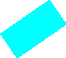
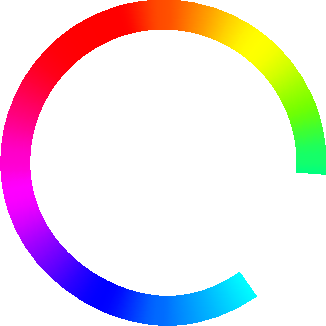
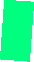

In [77]:
display(HTML(open("..\\web\\footer.html", "r", encoding="utf-8").read()))